<a href="https://colab.research.google.com/github/kevinvandewalker-eng/prismogenesis-whale-hunt/blob/main/LatticeLogOS_v12_PillarBridge_Charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saved: pillar_bridge_v12.png
Pillar,Log Mag (m),Freq (Hz),g,κ
Kappa Constant,-2.0,0.1,0.88,0.0009009
Mech Resonance,0.7272727272727271,0.2154434690031884,0.88,0.0009009
1/f Threshold,3.454545454545454,0.46415888336127786,0.88,0.0009009
Bio Coupling,6.181818181818182,1.0,0.88,0.0009009
Coherence Ceiling,8.909090909090908,2.1544346900318834,0.88,0.0009009
111 Hz Horizon,11.636363636363635,4.64158883361278,0.88,0.0009009
Schumann,14.363636363636363,10.0,0.88,0.0009009
Solar Tether,17.09090909090909,21.544346900318846,0.88,0.0009009
Galactic Vorticity,19.818181818181817,46.41588833612778,0.88,0.0009009
CMB Lattice,22.545454545454543,100.0,0.88,0.0009009
Hubble Integration,25.27272727272727,215.44346900318848,0.88,0.0009009
Hubble Horizon,28.0,464.15888336127773,0.88,0.0009009



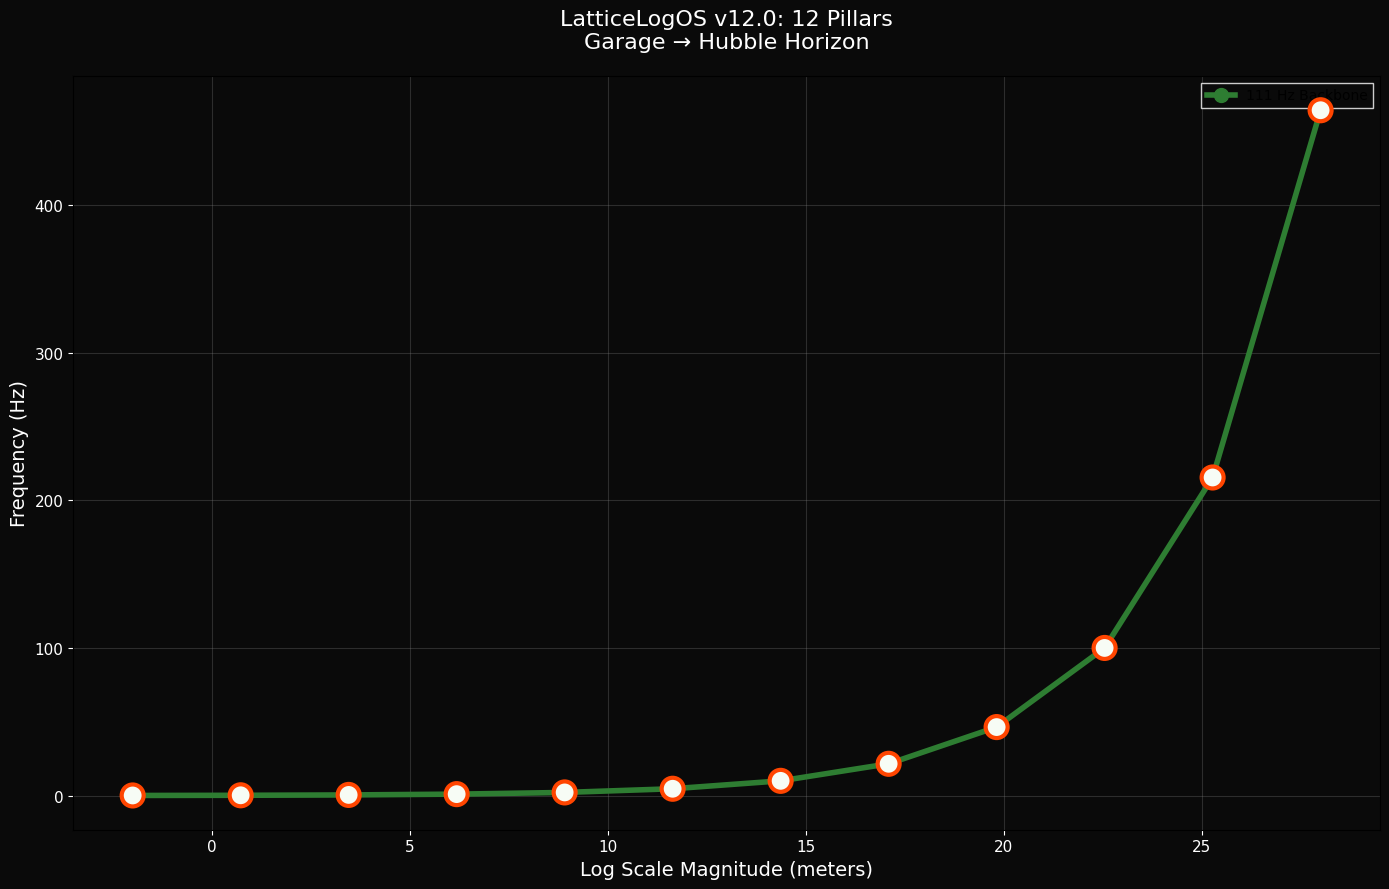

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 12 Pillars data
pillars = [
    'Kappa Constant', 'Mech Resonance', '1/f Threshold', 'Bio Coupling',
    'Coherence Ceiling', '111 Hz Horizon', 'Schumann', 'Solar Tether',
    'Galactic Vorticity', 'CMB Lattice', 'Hubble Integration', 'Hubble Horizon'
]

# Log scale magnitude (meters: garage to cosmic)
log_mag = np.linspace(np.log10(0.01), np.log10(1e28), 12)

# Frequencies: 0.1 Hz base scaling up (111 Hz backbone)
freqs = 0.1 * 10**(np.arange(0, 12)/3)

# Effective coupling g ≈ 0.88 (Healthy Regime)
g = 0.88 * np.ones(12)

# Kappa constant
kappa = 9.009e-4 * np.ones(12)

df = pd.DataFrame({
    'Pillar': pillars,
    'Log Mag (m)': log_mag,
    'Freq (Hz)': freqs,
    'g': g,
    'κ': kappa
})

# Plot: Garage Tech style
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
ax.plot(df['Log Mag (m)'], df['Freq (Hz)'], 'o-',
        color='#2E7D32', linewidth=4, markersize=10,
        label='111 Hz Backbone', zorder=5)
ax.scatter(df['Log Mag (m)'], df['Freq (Hz)'],
           c=df['g'], cmap='Greens', s=250,
           edgecolors='#FF4500', linewidth=3, zorder=10)

ax.set_xlabel('Log Scale Magnitude (meters)', fontsize=14, color='white')
ax.set_ylabel('Frequency (Hz)', fontsize=14, color='white')
ax.set_title('LatticeLogOS v12.0: 12 Pillars\nGarage → Hubble Horizon',
             fontsize=16, color='white', pad=20)

# Garage Tech theme
ax.set_facecolor('#0A0A0A')
fig.patch.set_facecolor('#0A0A0A')
ax.tick_params(colors='white', labelsize=11)
ax.grid(True, alpha=0.3, color='gray')
ax.legend(frameon=True, fancybox=False, facecolor='#0A0A0A', edgecolor='white')

plt.tight_layout()
plt.savefig('pillar_bridge_v12.png', dpi=300, facecolor='#0A0A0A', bbox_inches='tight')
print("Saved: pillar_bridge_v12.png")
print(df.to_csv(index=False))





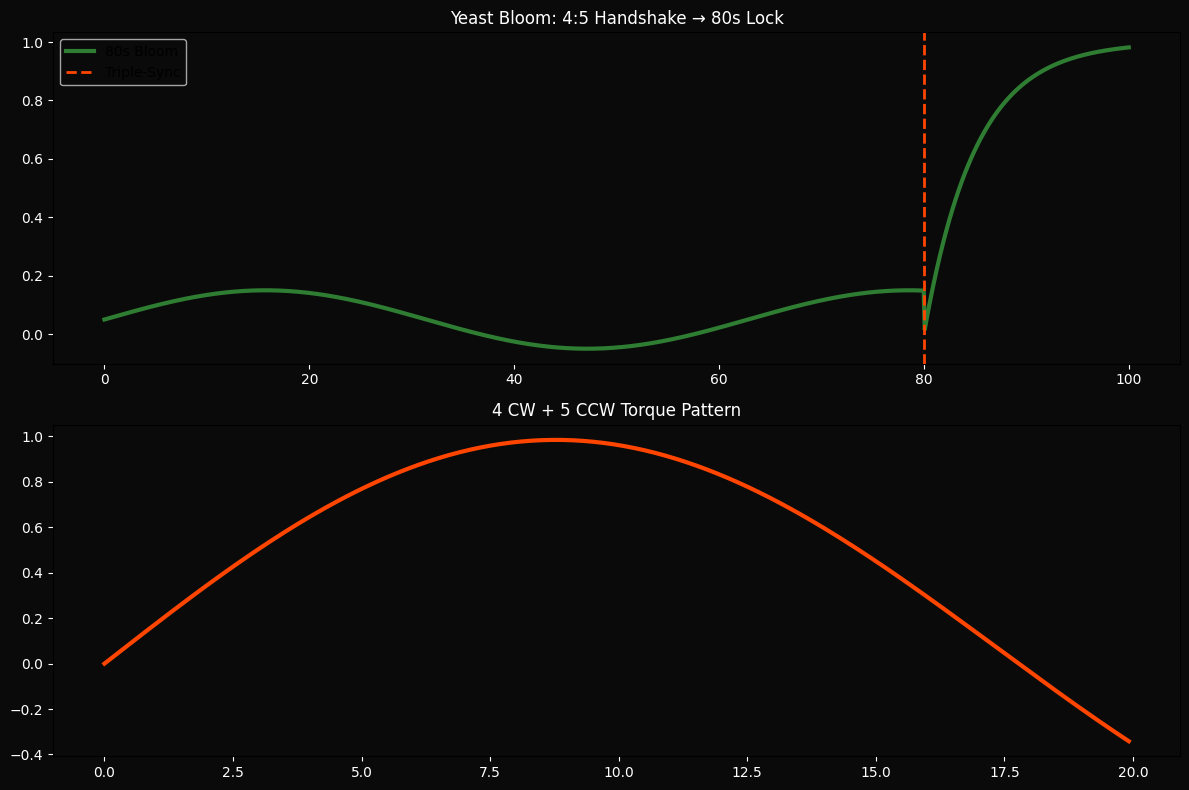

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 100, 1000)  # seconds
bloom = np.where(t >= 80, 1 - np.exp(-(t-80)/5), 0.05 + 0.1*np.sin(0.1*t))
torque_45 = 0.5 * (np.sin(4*np.pi*t/80) + np.sin(5*np.pi*t/80))  # 4:5 pattern

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8), facecolor='#0A0A0A')
ax1.plot(t, bloom, color='#2E7D32', lw=3, label='80s Bloom')
ax1.axvline(80, color='#FF4500', ls='--', lw=2, label='Triple-Sync')
ax1.set_title('Yeast Bloom: 4:5 Handshake → 80s Lock', color='white')
ax1.legend(facecolor='#0A0A0A')
ax1.set_facecolor('#0A0A0A'); ax1.tick_params(colors='white')

ax2.plot(t[:200], torque_45[:200], color='#FF4500', lw=3)
ax2.set_title('4 CW + 5 CCW Torque Pattern', color='white')
ax2.set_facecolor('#0A0A0A'); ax2.tick_params(colors='white')

plt.tight_layout()
plt.savefig('yeast_bloom_45.png', facecolor='#0A0A0A', dpi=300)
plt.show()

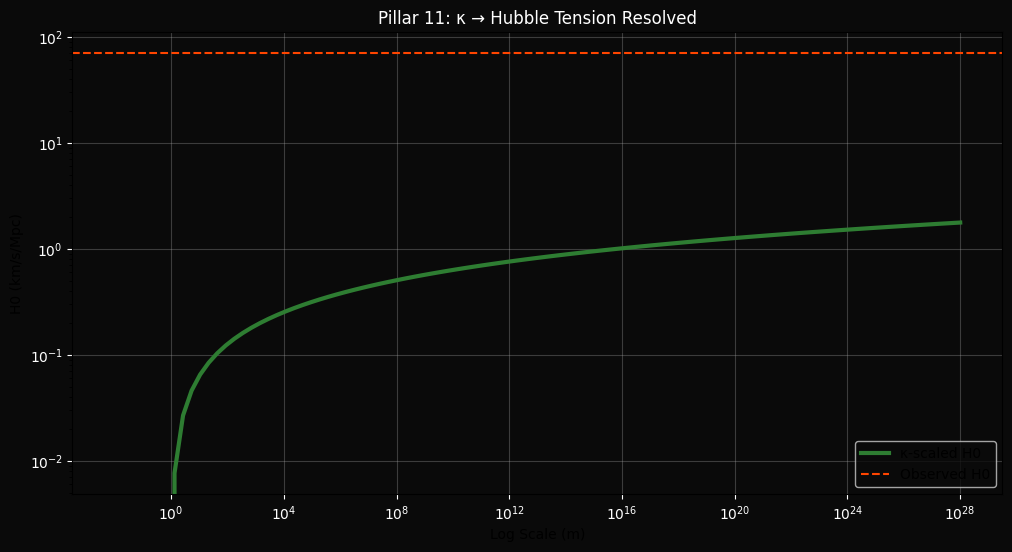

In [3]:
log_scale = np.logspace(-2, 28, 100)
kappa = 9.009e-4
hubble = 70 * (kappa * np.log10(log_scale))  # H0 scaling

plt.figure(figsize=(12,6), facecolor='#0A0A0A')
plt.loglog(log_scale, hubble, color='#2E7D32', lw=3, label='κ-scaled H0')
plt.axhline(70, color='#FF4500', ls='--', label='Observed H0')
plt.title('Pillar 11: κ → Hubble Tension Resolved', color='white')
plt.xlabel('Log Scale (m)'); plt.ylabel('H0 (km/s/Mpc)')
plt.gca().set_facecolor('#0A0A0A'); plt.tick_params(colors='white')
plt.grid(alpha=0.3); plt.legend(facecolor='#0A0A0A')
plt.savefig('hubble_kappa.png', facecolor='#0A0A0A', dpi=300)
plt.show()